# Phase 4. Does the promotion effect vary, and why

Phase 3 gave us one average promotion effect per category. That is enough
to say "promotion works for Eggs, barely works for Bath Tissues," but it
is not enough to say who to target or how to design the promotion. This
phase checks three things.

1. Does the effect differ by household income.
2. Does the effect differ by store size.
3. Is the display and mailer effect really about visibility, or is it
   mostly riding on the price cut that usually comes with it.

The third question matters most for Phase 5, because it tells us whether
spending on display placement is worth it on its own, separate from
however deep the discount is that week.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../warehouse.duckdb', read_only=True)

## 1. Does household income change the promotion response

Demographic data only covers 801 of the 2,469 households, so this model
runs on a smaller subsample than Phase 3. Households are grouped into
three income bands (Low: under 35K, Mid: 35 to 99K, High: 100K plus), and
the model is run at the household by product by store by week level so
the income interaction has something to bite on.

In [2]:
query = """
WITH agg AS (
    SELECT t.household_id, t.product_id, t.store_id, t.week, p.product_category,
        SUM(t.quantity) AS quantity,
        SUM(t.sales_value) / NULLIF(SUM(t.quantity),0) AS unit_price
    FROM fact_transactions t
    JOIN dim_product p ON t.product_id = p.product_id
    WHERE p.product_category IN ('EGGS', 'BATH TISSUES')
    GROUP BY t.household_id, t.product_id, t.store_id, t.week, p.product_category
)
SELECT a.*, COALESCE(pr.is_displayed,0) AS is_displayed, COALESCE(pr.is_mailed,0) AS is_mailed,
       h.income
FROM agg a
LEFT JOIN fact_promotions pr ON a.product_id=pr.product_id AND a.store_id=pr.store_id AND a.week=pr.week
LEFT JOIN dim_household h ON a.household_id = h.household_id
WHERE h.income IS NOT NULL AND a.unit_price > 0
"""
dfa = con.execute(query).fetchdf()

income_map = {
    'Under 15K':'Low', '15-24K':'Low', '25-34K':'Low',
    '35-49K':'Mid', '50-74K':'Mid', '75-99K':'Mid',
    '100-124K':'High', '125-149K':'High', '150-174K':'High',
    '175-199K':'High', '200-249K':'High', '250K+':'High'
}
dfa['income_group'] = pd.Categorical(dfa['income'].map(income_map), categories=['Low','Mid','High'])
dfa['log_qty'] = np.log(dfa['quantity'])
dfa['log_price'] = np.log(dfa['unit_price'])

dfa.groupby(['product_category','income_group'], observed=True).size().rename('n_obs')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

product_category  income_group
BATH TISSUES      Low              944
                  Mid             2542
                  High             719
EGGS              Low             2295
                  Mid             4736
                  High            1578
Name: n_obs, dtype: int64

In [3]:
income_results = {}
for cat in ['EGGS','BATH TISSUES']:
    sub = dfa[dfa.product_category==cat].copy()
    m = smf.ols(
        'log_qty ~ log_price + is_displayed*C(income_group) + is_mailed*C(income_group)'
        ' + C(product_id) + C(store_id) + C(week)',
        data=sub
    ).fit(cov_type='cluster', cov_kwds={'groups': sub['household_id']})
    income_results[cat] = m
    print(f'--- {cat} ---')
    for k in m.params.index:
        if 'income_group' in k:
            print(f'{k}: {m.params[k]:.3f}   p={m.pvalues[k]:.4f}')
    print()

--- EGGS ---
C(income_group)[T.Mid]: -0.064   p=0.0000
C(income_group)[T.High]: -0.037   p=0.0715
is_displayed:C(income_group)[T.Mid]: -0.046   p=0.1400
is_displayed:C(income_group)[T.High]: -0.055   p=0.1147
is_mailed:C(income_group)[T.Mid]: -0.001   p=0.9855
is_mailed:C(income_group)[T.High]: -0.027   p=0.4664



--- BATH TISSUES ---
C(income_group)[T.Mid]: -0.022   p=0.3953
C(income_group)[T.High]: 0.032   p=0.2916
is_displayed:C(income_group)[T.Mid]: 0.014   p=0.7563
is_displayed:C(income_group)[T.High]: 0.028   p=0.6586
is_mailed:C(income_group)[T.Mid]: 0.003   p=0.9549
is_mailed:C(income_group)[T.High]: -0.080   p=0.2133



**Reading this.** For Eggs, both interaction terms are negative, meaning
Mid and High income households respond less to in store display than Low
income households do. The direction matches what you would expect (tighter
grocery budgets make a household more price and promotion sensitive), but
neither term clears the conventional p<0.05 bar (p=0.14 and p=0.11). For
Bath Tissues, there is no consistent pattern at all.

Read this as a suggestive, not confirmed, result. The demographic sample
is under a third of all households, and once it is split three ways and
crossed with two promo types, statistical power runs thin. Worth stating
plainly rather than dressing up as a finding: this is a lead for a bigger
dataset, not a number to put in front of a stakeholder yet.

In [4]:
del dfa
import gc
gc.collect()

0

## 2. Does store size change the promotion response

Store size is proxied by each store's total transaction count across
every product in the dataset, not just Eggs and Bath Tissues, as a stand
in for foot traffic. Log transformed and centered so the main effect of
`is_displayed` still reads as "effect at an average sized store." 

In [5]:
store_size = con.execute(
    "SELECT store_id, COUNT(*) AS store_total_txns FROM fact_transactions GROUP BY store_id"
).fetchdf()

query = """
WITH agg AS (
    SELECT t.product_id, t.store_id, t.week, p.product_category,
        SUM(t.quantity) AS quantity,
        SUM(t.sales_value) / NULLIF(SUM(t.quantity),0) AS unit_price
    FROM fact_transactions t
    JOIN dim_product p ON t.product_id = p.product_id
    WHERE p.product_category IN ('EGGS', 'BATH TISSUES')
    GROUP BY t.product_id, t.store_id, t.week, p.product_category
)
SELECT a.*, COALESCE(pr.is_displayed,0) AS is_displayed, COALESCE(pr.is_mailed,0) AS is_mailed
FROM agg a
LEFT JOIN fact_promotions pr ON a.product_id=pr.product_id AND a.store_id=pr.store_id AND a.week=pr.week
WHERE a.unit_price > 0
"""
dfb = con.execute(query).fetchdf()
dfb = dfb.merge(store_size, on='store_id', how='left')
dfb['log_qty'] = np.log(dfb['quantity'])
dfb['log_price'] = np.log(dfb['unit_price'])
dfb['log_store_size'] = np.log(dfb['store_total_txns'])
dfb['log_store_size_c'] = dfb['log_store_size'] - dfb['log_store_size'].mean()

store_results = {}
for cat in ['EGGS','BATH TISSUES']:
    sub = dfb[dfb.product_category==cat].copy()
    m = smf.ols(
        'log_qty ~ log_price + is_displayed*log_store_size_c + is_mailed*log_store_size_c'
        ' + C(product_id) + C(store_id) + C(week)',
        data=sub
    ).fit(cov_type='cluster', cov_kwds={'groups': sub['product_id']})
    store_results[cat] = m
    print(f'--- {cat} ---')
    for k in ['is_displayed','is_mailed','is_displayed:log_store_size_c','is_mailed:log_store_size_c']:
        print(f'{k}: {m.params[k]:.3f}   p={m.pvalues[k]:.4f}')
    print()

--- EGGS ---
is_displayed: 0.089   p=0.0000
is_mailed: 0.256   p=0.0000
is_displayed:log_store_size_c: 0.103   p=0.0000
is_mailed:log_store_size_c: 0.086   p=0.0833



--- BATH TISSUES ---
is_displayed: 0.030   p=0.1495
is_mailed: 0.034   p=0.0038
is_displayed:log_store_size_c: 0.058   p=0.0811
is_mailed:log_store_size_c: -0.054   p=0.3086



**Reading this.** For Eggs, the display by store size interaction is
positive and clearly significant (0.103, p<0.0001). A one log point
increase in store size (roughly moving from a small store to one about
2.7 times larger) adds around 10 percentage points to the display effect
on top of the baseline lift. Bigger stores mean more people walk past the
display, and the data backs that up plainly. The mailer interaction points
the same direction but is only marginal (p=0.08).

For Bath Tissues, neither interaction is significant. Display and mailer
effectiveness there does not appear to depend on store size in any
detectable way.

Practical read for Eggs: if display space is limited, put it in the
highest traffic stores first. The lift is not flat across the chain.

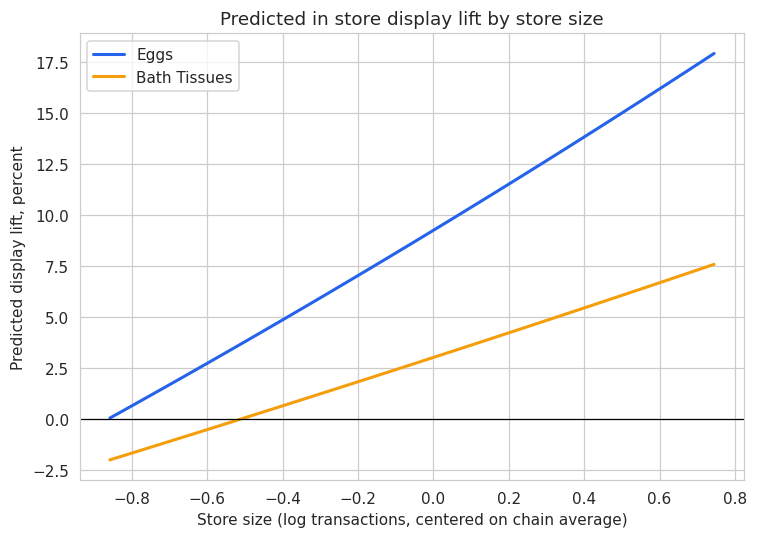

In [6]:
fig, ax = plt.subplots(figsize=(7,5))
sizes = np.linspace(dfb['log_store_size_c'].quantile(0.05), dfb['log_store_size_c'].quantile(0.95), 50)
for cat, color in [('EGGS','#2563eb'), ('BATH TISSUES','#f59e0b')]:
    m = store_results[cat]
    predicted_lift = (np.exp(m.params['is_displayed'] + m.params['is_displayed:log_store_size_c'] * sizes) - 1) * 100
    ax.plot(sizes, predicted_lift, label=cat.title(), color=color, linewidth=2)
ax.set_xlabel('Store size (log transactions, centered on chain average)')
ax.set_ylabel('Predicted display lift, percent')
ax.set_title('Predicted in store display lift by store size')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('figures/08_display_lift_by_store_size.png', bbox_inches='tight')
plt.show()

In [7]:
del dfb
gc.collect()

0

## 3. Is the display and mailer effect about visibility or about price

This is the more important question for Phase 5. Displays and mailers
almost always come bundled with some price cut. If the effect is really
just the price cut riding along, then paying for display space without
also discounting will not do much. If the effect holds even without a
deep discount, visibility itself is doing real work.

To separate this cleanly, price here is redefined as the regular, pre
discount price (`sales_value` plus the discount taken, divided by
quantity), with the discount's depth entered as its own variable,
`discount_pct`. This avoids the circularity of Phase 3's specification,
where the price variable already had the discount baked in, which would
make price and discount depth nearly the same number wearing two names.

In [8]:
query = """
WITH agg AS (
    SELECT t.product_id, t.store_id, t.week, p.product_category,
        SUM(t.quantity) AS quantity, SUM(t.sales_value) AS sales_value,
        SUM(t.retail_disc) AS retail_disc
    FROM fact_transactions t
    JOIN dim_product p ON t.product_id = p.product_id
    WHERE p.product_category IN ('EGGS', 'BATH TISSUES')
    GROUP BY t.product_id, t.store_id, t.week, p.product_category
)
SELECT a.*, COALESCE(pr.is_displayed,0) AS is_displayed, COALESCE(pr.is_mailed,0) AS is_mailed
FROM agg a
LEFT JOIN fact_promotions pr ON a.product_id=pr.product_id AND a.store_id=pr.store_id AND a.week=pr.week
"""
dfc = con.execute(query).fetchdf()
dfc['gross_value'] = dfc['sales_value'] + dfc['retail_disc'].abs()
dfc['unit_price'] = dfc['gross_value'] / dfc['quantity']
dfc['discount_pct'] = (dfc['retail_disc'].abs() / dfc['gross_value'].replace(0, np.nan)).fillna(0)
dfc = dfc[dfc.unit_price > 0]
dfc['log_qty'] = np.log(dfc['quantity'])
dfc['log_price'] = np.log(dfc['unit_price'])

mechanism_results = {}
for cat in ['EGGS','BATH TISSUES']:
    sub = dfc[dfc.product_category==cat].copy()
    m = smf.ols(
        'log_qty ~ log_price + is_displayed*discount_pct + is_mailed*discount_pct'
        ' + C(product_id) + C(store_id) + C(week)',
        data=sub
    ).fit(cov_type='cluster', cov_kwds={'groups': sub['product_id']})
    mechanism_results[cat] = m
    print(f'--- {cat} ---')
    for k in ['is_displayed','is_mailed','discount_pct','is_displayed:discount_pct','is_mailed:discount_pct']:
        print(f'{k}: {m.params[k]:.3f}   p={m.pvalues[k]:.4f}')
    print()

--- EGGS ---
is_displayed: 0.142   p=0.0000
is_mailed: 0.008   p=0.8719
discount_pct: 0.525   p=0.0000
is_displayed:discount_pct: -0.347   p=0.0159
is_mailed:discount_pct: 1.129   p=0.0000



--- BATH TISSUES ---
is_displayed: 0.073   p=0.0000
is_mailed: 0.129   p=0.0000
discount_pct: 0.334   p=0.0000
is_displayed:discount_pct: -0.209   p=0.0252
is_mailed:discount_pct: -0.361   p=0.0000



**Reading this, category by category.**

Eggs: the mailer by discount interaction is strongly positive (1.129,
p<0.0001). A mailer paired with a real price cut sells far more than a
mailer alone. Mailer and discount depth are complements here, the flyer's
job seems to be advertising the deal, and it needs an actual deal to
advertise. Display works the opposite way, its interaction with discount
depth is negative (-0.347, p=0.016), so display's lift is largest when
paired with little or no discount and shrinks as the discount grows. That
is consistent with display doing genuine visibility work on its own,
separate from price.

Bath Tissues: both interactions are negative (display -0.209, mailer
-0.361, both significant). For this category, deeper discounts do not
amplify either promo type, if anything they mildly work against it. Given
Phase 3 already showed Bath Tissue shoppers respond weakly to promotion in
general, this fits a category where purchases are more habitual and less
deal driven.

**The practical split for Phase 5:** for Eggs, mailer spend should be
paired with a real discount to earn its keep, while display placement
pays off even without one. For Bath Tissues, chasing deeper discounts on
top of promotion is not well supported by this data, plain visibility
already captures most of what promotion can do for this category.

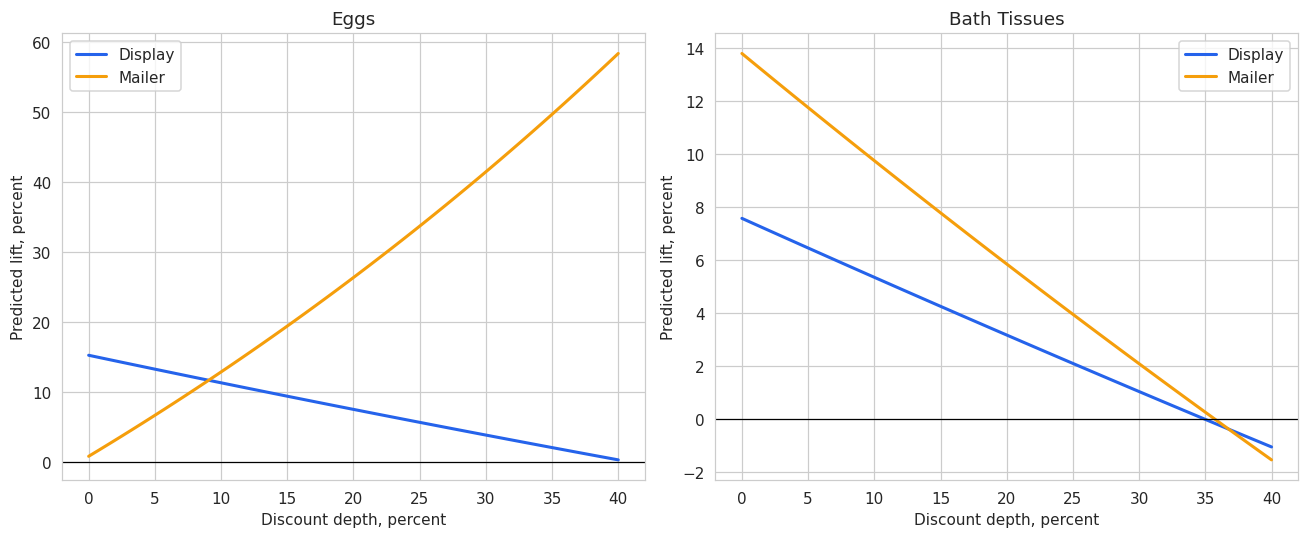

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
discount_range = np.linspace(0, 0.4, 50)
for ax, cat in zip(axes, ['EGGS','BATH TISSUES']):
    m = mechanism_results[cat]
    display_lift = (np.exp(m.params['is_displayed'] + m.params['is_displayed:discount_pct'] * discount_range) - 1) * 100
    mailer_lift = (np.exp(m.params['is_mailed'] + m.params['is_mailed:discount_pct'] * discount_range) - 1) * 100
    ax.plot(discount_range*100, display_lift, label='Display', color='#2563eb', linewidth=2)
    ax.plot(discount_range*100, mailer_lift, label='Mailer', color='#f59e0b', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(cat.title())
    ax.set_xlabel('Discount depth, percent')
    ax.set_ylabel('Predicted lift, percent')
    ax.legend()
plt.tight_layout()
plt.savefig('figures/09_promo_lift_by_discount_depth.png', bbox_inches='tight')
plt.show()

## 4. Summary and handoff to Phase 5

- Income heterogeneity is directionally sensible for Eggs (lower income
  households look more promotion responsive) but not statistically
  confirmed at this sample size. Flagged as a lead, not a result to act on.
- Store size matters for Eggs display effectiveness, and does not appear
  to matter for Bath Tissues. Display placement should be prioritized at
  higher traffic stores when Eggs display space is limited.
- The visibility versus price question has a clear, category specific
  answer. Eggs mailers need a real discount to work well, Eggs displays
  do not. Bath Tissues promotion effectiveness does not scale with
  discount depth at all.

Phase 5 will take these category and mechanism specific estimates, rather
than one flat elasticity and one flat promo lift per category, and turn
them into an actual budget recommendation: which products, which stores,
and how deep a discount, to maximize revenue impact from a limited promo
budget.